In [1]:
import pandas as pd
import numpy as np
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Step 1: Load Data with Dummies ---
try:
    # Use the file previously created/uploaded
    df_with_dummies = pd.read_csv("DC_Master_Data_With_Dummies.csv", parse_dates=['Date'], index_col='Date')
    # Ensure the frequency is set correctly
    df_with_dummies = df_with_dummies.asfreq('QS-JAN')
    print("Data with dummies loaded successfully.")

    # --- Step 2: Prepare Target and Base Predictors ---
    print("Preparing stationary variables and lags...")

    # Target variable (stationary)
    target = df_with_dummies['House_Index'].diff(1).rename('Target_House_Index_diff1')

    # Create stationary versions of predictors (as needed for lagging)
    predictors_stationary = pd.DataFrame(index=df_with_dummies.index)
    predictors_stationary['Unemployment_Rate'] = df_with_dummies['Unemployment_Rate'] # I(0)
    predictors_stationary['CPI_diff1'] = df_with_dummies['CPI'].diff(1)
    predictors_stationary['Poverty_Rate_diff1'] = df_with_dummies['Poverty_Rate'].diff(1)
    predictors_stationary['Median_Household_Income_diff1'] = df_with_dummies['Median_Household_Income'].diff(1)
    predictors_stationary['Interest_Rate_diff1'] = df_with_dummies['Interest_Rate'].diff(1)
    predictors_stationary['Mortgage_Rate_diff1'] = df_with_dummies['Mortgage_Rate'].diff(1)
    predictors_stationary['Population_diff2'] = df_with_dummies['Population'].diff(2)
    predictors_stationary['GDP_diff3'] = df_with_dummies['GDP'].diff(3)

    # --- Step 3: Create Predictor Matrix (X) with Dummies and Lags ---
    X_lasso = df_with_dummies[['Recession', 'Hot_Market']].copy() # Start with dummies

    max_lag = 4
    predictor_cols = predictors_stationary.columns # Get list of stationary predictors

    # Add lags 1 through max_lag for each stationary predictor
    for col in predictor_cols:
        for lag in range(1, max_lag + 1):
            X_lasso[f'{col}_L{lag}'] = predictors_stationary[col].shift(lag)

    # --- Step 4: Combine Target and Predictors, Drop NaNs ---
    df_lasso_input = pd.concat([target, X_lasso], axis=1)

    # Drop rows with NaNs (introduced by differencing in target/predictors AND lagging)
    # Max lag is 4, max initial diff for predictors was 3. Need to drop at least 4 rows.
    initial_len = len(df_lasso_input)
    df_lasso_input.dropna(inplace=True)
    final_len = len(df_lasso_input)
    print(f"Combined DataFrame created. Dropped {initial_len - final_len} rows due to NaNs.")
    print(f"Final shape for LASSO input: {df_lasso_input.shape}")


    # --- Step 5: Save the Prepared Data ---
    output_file_lasso = 'DC_Data_For_Lasso.csv'
    # Use reset_index() to include the 'Date' column in the CSV
    df_lasso_input.reset_index().to_csv(output_file_lasso, index=False)
    print(f"\nData prepared for LASSO/Regression saved to {output_file_lasso}")

    # --- Step 6: Display Sample of Prepared Data ---
    print("\n--- Head of data prepared for LASSO ---")
    print(df_lasso_input.head())
    print("\n--- Tail of data prepared for LASSO ---")
    print(df_lasso_input.tail())


except FileNotFoundError:
    print("Error: The file 'DC_Master_Data_With_Dummies.csv' was not found.")
except KeyError as e:
    print(f"Error: A required column was not found: {e}")
    print("Please check column names.")
except Exception as e:
    print(f"An error occurred during analysis: {e}")

Data with dummies loaded successfully.
Preparing stationary variables and lags...
Combined DataFrame created. Dropped 7 rows due to NaNs.
Final shape for LASSO input: (133, 35)

Data prepared for LASSO/Regression saved to DC_Data_For_Lasso.csv

--- Head of data prepared for LASSO ---
            Target_House_Index_diff1  Recession  Hot_Market  \
Date                                                          
1991-10-01                      1.60          0           0   
1992-01-01                      0.31          0           0   
1992-04-01                     -0.82          0           0   
1992-07-01                      0.82          0           0   
1992-10-01                      0.11          0           0   

            Unemployment_Rate_L1  Unemployment_Rate_L2  Unemployment_Rate_L3  \
Date                                                                           
1991-10-01                   6.1                   5.2                   5.3   
1992-01-01                   6.2 

Data loaded successfully.

Preparing data...
Features shape: (133, 34)
Target shape: (133,)

Setting up TimeSeriesSplit and LassoCV...

Running LassoCV to find optimal alpha and fit model...

Optimal alpha found via cross-validation: 0.847465

Extracting feature coefficients...

Number of features selected by Lasso: 3

--- Selected Features and Coefficients (Sorted) ---
GDP_diff3_L1    0.744871
Hot_Market      0.193205
Recession      -0.517830
dtype: float64

Generating feature importance plot...


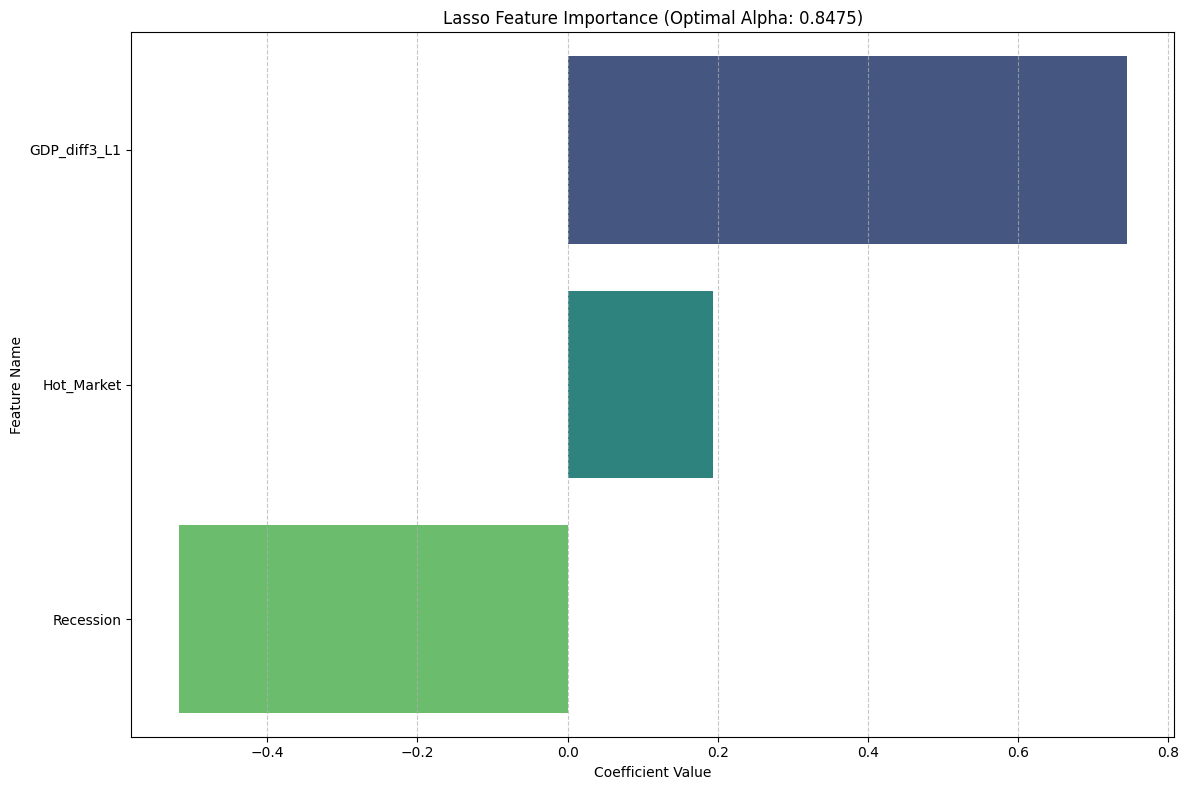

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

# Load the data prepared in the previous step
try:
    df_lasso_input = pd.read_csv('DC_Data_For_Lasso.csv', parse_dates=['Date'], index_col='Date')
    print("Data loaded successfully.")

    # --- Step 1: Prepare Data for Lasso ---
    print("\nPreparing data...")
    # Define Target and Features
    # Based on E_Lasso.ipynb, the target is 'Target_House_Index_diff1'
    target_col = 'Target_House_Index_diff1'
    if target_col not in df_lasso_input.columns:
        raise KeyError(f"Target column '{target_col}' not found in the DataFrame.")

    X = df_lasso_input.drop(columns=[target_col])
    y = df_lasso_input[target_col]

    # Ensure all features are numeric (dummy variables should already be 0/1)
    X = X.apply(pd.to_numeric, errors='coerce')
    # Check for any NaNs introduced by coercion (shouldn't happen if data was clean)
    if X.isnull().values.any():
        print("Warning: NaNs found in feature data after numeric conversion. Filling with 0.")
        X = X.fillna(0) # Or use a more sophisticated imputation if needed

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")

    # --- Step 2: Set up Time Series Cross-Validation and Lasso ---
    print("\nSetting up TimeSeriesSplit and LassoCV...")
    # TimeSeriesSplit for cross-validation
    # n_splits determines how many train/test splits are created
    # We choose a gap to avoid leakage between train and test folds in time series
    tscv = TimeSeriesSplit(n_splits=5, gap=0) # Adjust n_splits if needed

    # Create a pipeline with scaling and LassoCV
    # LassoCV automatically finds the best alpha using cross-validation
    pipeline = Pipeline([
        ('scaler', StandardScaler()), # Scale features
        ('lasso', LassoCV(cv=tscv, random_state=42, max_iter=10000, n_jobs=-1)) # Lasso with Cross-Validation
    ])

    # --- Step 3: Run Lasso Selection ---
    print("\nRunning LassoCV to find optimal alpha and fit model...")
    pipeline.fit(X, y)

    # Extract the fitted LassoCV model and the scaler
    lasso_cv_model = pipeline.named_steps['lasso']
    scaler = pipeline.named_steps['scaler']

    # Get the optimal alpha found
    optimal_alpha = lasso_cv_model.alpha_
    print(f"\nOptimal alpha found via cross-validation: {optimal_alpha:.6f}")

    # --- Step 4: Measure Feature Importance (Coefficients) ---
    print("\nExtracting feature coefficients...")
    coefficients = lasso_cv_model.coef_

    # Create a Series for easier handling
    feature_importance = pd.Series(coefficients, index=X.columns)

    # Filter out features with zero coefficients (Lasso performs feature selection)
    selected_features = feature_importance[feature_importance != 0].sort_values(ascending=False)

    print(f"\nNumber of features selected by Lasso: {len(selected_features)}")
    print("\n--- Selected Features and Coefficients (Sorted) ---")
    if selected_features.empty:
        print("Lasso selected no features (all coefficients are zero).")
        print("This might happen if alpha is too high or features have low predictive power.")
    else:
        print(selected_features)

    # --- Step 5: Visualize Feature Importance ---
    print("\nGenerating feature importance plot...")
    if not selected_features.empty:
        plt.figure(figsize=(12, 8))
        sns.barplot(x=selected_features.values, y=selected_features.index, palette='viridis')
        plt.title(f'Lasso Feature Importance (Optimal Alpha: {optimal_alpha:.4f})')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Feature Name')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping plot generation as no features were selected.")

except FileNotFoundError:
    print("Error: The file 'DC_Data_For_Lasso.csv' was not found.")
except KeyError as e:
    print(f"Error: A required column was not found: {e}")
    print("Please ensure 'DC_Data_For_Lasso.csv' contains the 'Target_House_Index_diff1' column and feature columns.")
except Exception as e:
    print(f"An error occurred during analysis: {e}")


In [13]:
import pandas as pd
import numpy as np

# --- Configuration ---
# Input file provided by the user
input_file = 'DC_Master_Data_With_Dummies.csv'
# New output file for this specific feature set
output_file = 'DC_Data_For_Lasso_3Feat.csv'
print(f"Attempting to load base data from: {input_file}")

try:
    # --- Step 1: Load Data ---
    # Load the master data with dummy variables
    df_master = pd.read_csv(input_file, parse_dates=['Date'], index_col='Date')
    print(f"Loaded data successfully. Shape: {df_master.shape}")

    # Select necessary columns + Date index
    # Now including Hot_Market as it's available in the input file
    cols_needed = ['House_Index', 'GDP', 'Recession', 'Hot_Market']
    if not all(col in df_master.columns for col in cols_needed):
        # Check for variations in naming if error occurs
        print(f"Available columns: {df_master.columns.tolist()}")
        raise KeyError(f"One or more required columns ({cols_needed}) not found in {input_file}")

    df_subset = df_master[cols_needed].copy()
    print(f"Selected necessary columns. Shape: {df_subset.shape}")

    # --- Step 2: Calculate Target Variable ---
    # Target: First difference of House_Index
    df_subset['Target_House_Index_diff1'] = df_subset['House_Index'].diff(1)
    print("Calculated Target_House_Index_diff1.")

    # --- Step 3: Calculate Required Feature Transformations ---
    # Feature 1: GDP differenced 3 times, then lagged 1 quarter
    df_subset['GDP_diff3'] = df_subset['GDP'].diff(3)
    df_subset['GDP_diff3_L1'] = df_subset['GDP_diff3'].shift(1)
    print("Calculated GDP_diff3_L1.")

    # Features 2 & 3: Recession and Hot_Market are already in the correct format (dummies)
    # No transformation needed, just select them.

    # --- Step 4: Combine into Final DataFrame for Lasso ---
    # Select the target and the final features
    # Now including Hot_Market
    final_cols = ['Target_House_Index_diff1', 'Recession', 'Hot_Market', 'GDP_diff3_L1']
    df_lasso_input_new = df_subset[final_cols].copy()
    print(f"Created DataFrame with target and required features. Shape before dropna: {df_lasso_input_new.shape}")

    # --- Step 5: Drop Rows with NaNs ---
    # NaNs are introduced by diff(1) (1 row), diff(3) (3 rows), shift(1) (1 row). Max lookback is 4 rows.
    original_rows = df_lasso_input_new.shape[0]
    df_lasso_input_new.dropna(inplace=True)
    rows_after_dropna = df_lasso_input_new.shape[0]
    rows_dropped = original_rows - rows_after_dropna
    print(f"Dropped {rows_dropped} rows due to NaNs introduced by differencing/lagging.")
    print(f"Final shape for new Lasso input: {df_lasso_input_new.shape}")

    # Compare to original Lasso input size (133 rows from E_Lasso.ipynb output)
    original_lasso_rows = 133 # From notebook E output
    rows_gained = rows_after_dropna - original_lasso_rows
    print(f"Compared to original Lasso data ({original_lasso_rows} rows), we have gained {rows_gained} data points.")


    # --- Step 6: Save the New Data ---
    # Use reset_index() to include the 'Date' column in the CSV
    df_lasso_input_new.reset_index().to_csv(output_file, index=False)
    print(f"\nNew data prepared specifically for 3-feature Lasso saved to {output_file}")

    # --- Step 7: Display Sample of New Data ---
    print("\n--- Head of new data ---\n", df_lasso_input_new.head())
    print("\n--- Tail of new data ---\n", df_lasso_input_new.tail())


except FileNotFoundError:
    print(f"Error: The file '{input_file}' was not found.")
    print("Please ensure this file exists in the environment.")
except KeyError as e:
    print(f"Error: A required column was not found: {e}")
    print(f"Please ensure '{input_file}' contains Date, House_Index, GDP, Recession, Hot_Market columns.")
except Exception as e:
    print(f"An error occurred during analysis: {e}")

Attempting to load base data from: DC_Master_Data_With_Dummies.csv
Loaded data successfully. Shape: (140, 12)
Selected necessary columns. Shape: (140, 4)
Calculated Target_House_Index_diff1.
Calculated GDP_diff3_L1.
Created DataFrame with target and required features. Shape before dropna: (140, 4)
Dropped 4 rows due to NaNs introduced by differencing/lagging.
Final shape for new Lasso input: (136, 4)
Compared to original Lasso data (133 rows), we have gained 3 data points.

New data prepared specifically for 3-feature Lasso saved to DC_Data_For_Lasso_3Feat.csv

--- Head of new data ---
             Target_House_Index_diff1  Recession  Hot_Market  GDP_diff3_L1
Date                                                                     
1991-01-01                      0.54          1           0       132.032
1991-04-01                      0.15          0           0        75.150
1991-07-01                     -0.81          0           0       111.746
1991-10-01                      1.60

--- Running LassoCV on the updated dataset: DC_Data_For_Lasso_3Feat.csv ---
--- Using TimeSeriesSplit with n_splits = 5 ---
Data loaded successfully. Shape: (136, 4)
Features shape: (136, 3)
Target shape: (136,)

Setting up TimeSeriesSplit(n_splits=5) and LassoCV...

Running LassoCV to find optimal alpha and fit model...

Optimal alpha found via cross-validation (n_splits=5): 0.299124

Extracting feature coefficients...

Number of features selected by Lasso: 3

--- Selected Features and Coefficients (Sorted) ---
GDP_diff3_L1    1.163906
Hot_Market      0.606846
Recession      -0.893112
dtype: float64

Generating feature importance plot...


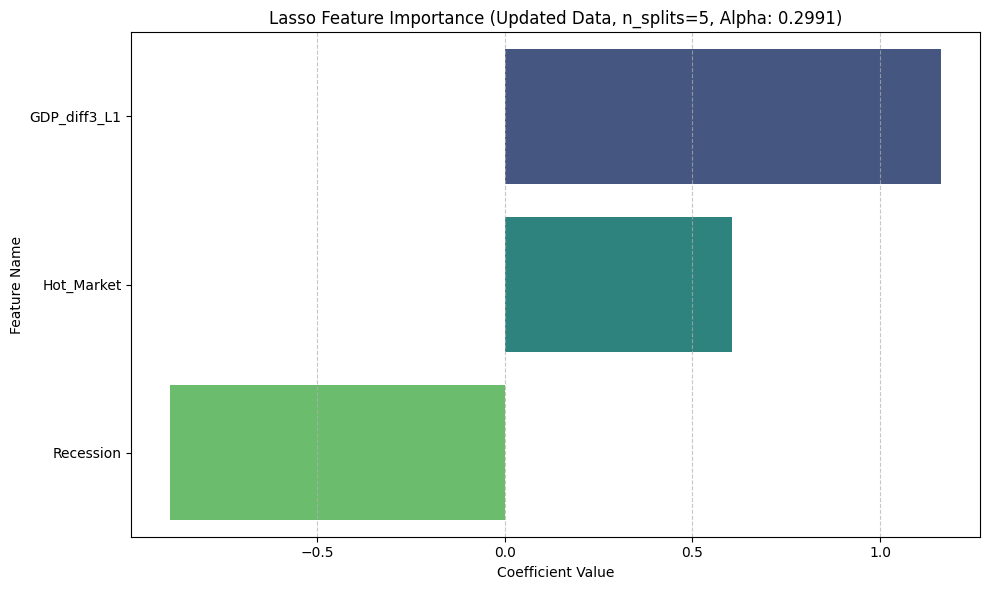


--- Comparison with previous run (133 rows, n_splits=5) ---
Previous Alpha (approx): 0.847465
Current Alpha: 0.299124

Previous Coefficients (approx):
GDP_diff3_L1: 0.745
Hot_Market:   0.193
Recession:   -0.518

Current Coefficients:
GDP_diff3_L1    1.163906
Hot_Market      0.606846
Recession      -0.893112
dtype: float64

Comment: Assess if the optimal alpha, selected features, and coefficient values are similar.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

# --- Configuration ---
input_file_new = 'DC_Data_For_Lasso_3Feat.csv'
n_splits_run = 5 # Use the stable split value
print(f"--- Running LassoCV on the updated dataset: {input_file_new} ---")
print(f"--- Using TimeSeriesSplit with n_splits = {n_splits_run} ---")

# --- Load and Prepare Data ---
try:
    df_lasso_input_updated = pd.read_csv(input_file_new, parse_dates=['Date'], index_col='Date')
    print(f"Data loaded successfully. Shape: {df_lasso_input_updated.shape}")

    # Define Target and Features
    target_col = 'Target_House_Index_diff1'
    if target_col not in df_lasso_input_updated.columns:
        raise KeyError(f"Target column '{target_col}' not found.")

    # Features are all other columns in this specific file
    X_updated = df_lasso_input_updated.drop(columns=[target_col])
    y_updated = df_lasso_input_updated[target_col]

    # Ensure all features are numeric (should be fine, but good practice)
    X_updated = X_updated.apply(pd.to_numeric, errors='coerce')
    if X_updated.isnull().values.any():
        print("Warning: NaNs found in feature data after numeric conversion. Filling with 0.")
        X_updated = X_updated.fillna(0)

    print(f"Features shape: {X_updated.shape}")
    print(f"Target shape: {y_updated.shape}")

    # --- Set up Time Series Cross-Validation and Lasso ---
    print(f"\nSetting up TimeSeriesSplit(n_splits={n_splits_run}) and LassoCV...")
    tscv_run = TimeSeriesSplit(n_splits=n_splits_run, gap=0)

    pipeline_run = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', LassoCV(cv=tscv_run, random_state=42, max_iter=10000, n_jobs=-1))
    ])

    # --- Run Lasso Selection ---
    print("\nRunning LassoCV to find optimal alpha and fit model...")
    pipeline_run.fit(X_updated, y_updated)

    # Extract the fitted LassoCV model and the scaler
    lasso_cv_model_run = pipeline_run.named_steps['lasso']
    scaler_run = pipeline_run.named_steps['scaler']

    # Get the optimal alpha found
    optimal_alpha_run = lasso_cv_model_run.alpha_
    print(f"\nOptimal alpha found via cross-validation (n_splits={n_splits_run}): {optimal_alpha_run:.6f}")

    # --- Measure Feature Importance (Coefficients) ---
    print("\nExtracting feature coefficients...")
    coefficients_run = lasso_cv_model_run.coef_
    feature_importance_run = pd.Series(coefficients_run, index=X_updated.columns)

    # Filter out features with zero coefficients (Lasso performs feature selection)
    # In this case, we expect all 3 features to be selected unless alpha changes significantly
    selected_features_run = feature_importance_run[feature_importance_run != 0].sort_values(ascending=False)

    print(f"\nNumber of features selected by Lasso: {len(selected_features_run)}")
    print("\n--- Selected Features and Coefficients (Sorted) ---")
    if selected_features_run.empty:
        print("Lasso selected no features (all coefficients are zero).")
    else:
        print(selected_features_run)

    # --- Visualize Feature Importance ---
    print("\nGenerating feature importance plot...")
    if not selected_features_run.empty:
        plt.figure(figsize=(10, 6)) # Adjusted size slightly for 3 features
        sns.barplot(x=selected_features_run.values, y=selected_features_run.index, palette='viridis')
        plt.title(f'Lasso Feature Importance (Updated Data, n_splits={n_splits_run}, Alpha: {optimal_alpha_run:.4f})')
        plt.xlabel('Coefficient Value')
        plt.ylabel('Feature Name')
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print("Skipping plot generation as no features were selected.")

    # --- Comparison Comment (Manual) ---
    print("\n--- Comparison with previous run (133 rows, n_splits=5) ---")
    # Previous results (approx): Alpha ~0.847, Coefs: GDP_diff3_L1 ~0.745, Hot_Market ~0.193, Recession ~-0.518
    print(f"Previous Alpha (approx): 0.847465")
    print(f"Current Alpha: {optimal_alpha_run:.6f}")
    print("\nPrevious Coefficients (approx):")
    print("GDP_diff3_L1: 0.745")
    print("Hot_Market:   0.193")
    print("Recession:   -0.518")
    print("\nCurrent Coefficients:")
    print(selected_features_run)
    print("\nComment: Assess if the optimal alpha, selected features, and coefficient values are similar.")


except FileNotFoundError:
    print(f"Error: The file '{input_file_new}' was not found.")
except KeyError as e:
    print(f"Error: A required column was not found: {e}")
except Exception as e:
    print(f"An error occurred during analysis: {e}")

--- Evaluating Ridge Regression Performance (3 Features) via Rolling Lagged Features ---
Using data: DC_Data_For_Lasso_3Feat.csv
Evaluating prediction of y(t) using features X(t-h+1) for h=1 to 8
Data loaded. Shape: (136, 4)

Running RidgeCV to find optimal alpha and model components...
Number of features for Ridge: 3
RidgeCV components retrieved (Optimal Alpha=25.9502).
Intercept: 2.1471
Coefficients: [-0.97961361  0.74489012  1.19610288]

Total observations: 136
Initial training size split point reference: 109
Test set size (for evaluation): 27

Evaluating for h=1 (using features lagged by 0 periods)
  Evaluating 27 predictions.
  Metrics for h=1 (Features L0):
    MAE:  4.067
    RMSE: 5.032
    MAPE: 2.290
    Dir Acc (%): 55.6

Evaluating for h=2 (using features lagged by 1 periods)
  Evaluating 26 predictions.
  Metrics for h=2 (Features L1):
    MAE:  4.494
    RMSE: 5.825
    MAPE: 2.529
    Dir Acc (%): 53.8

Evaluating for h=3 (using features lagged by 2 periods)
  Evaluating

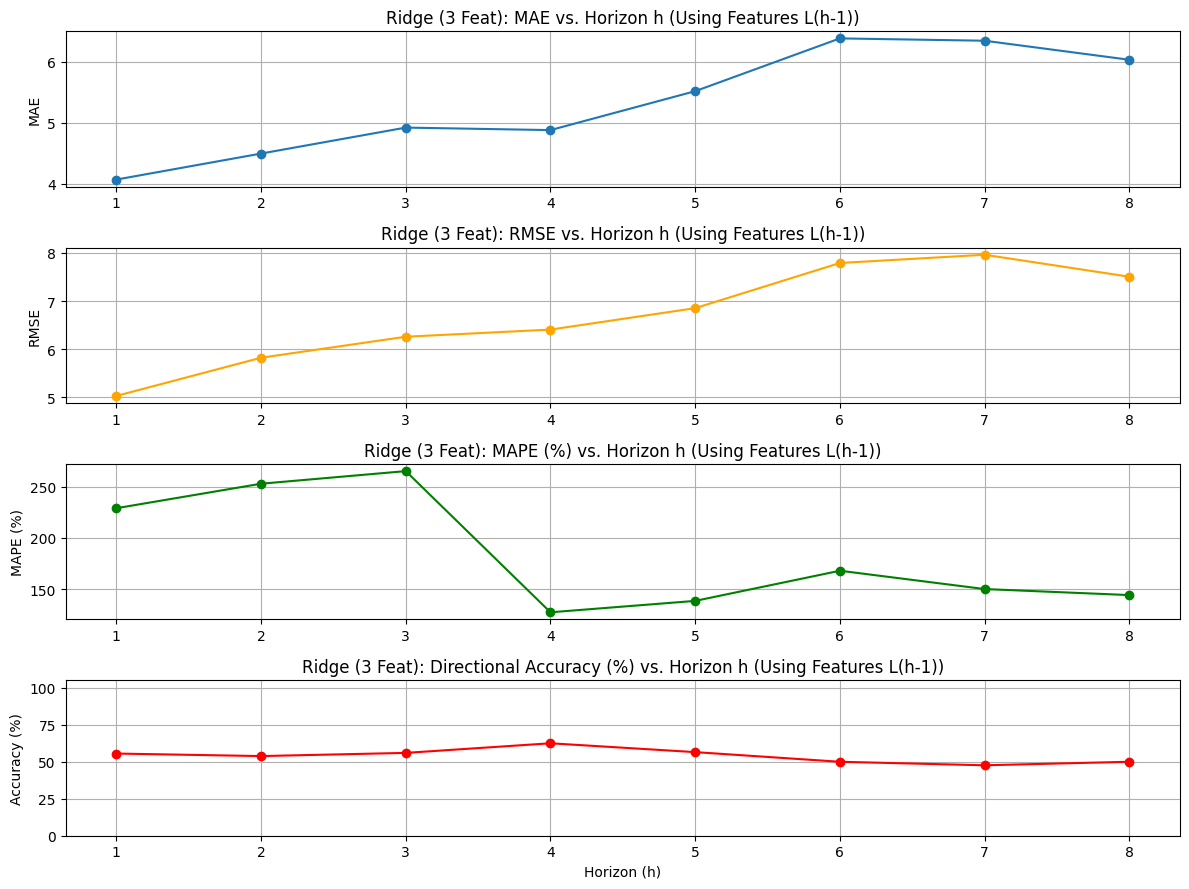

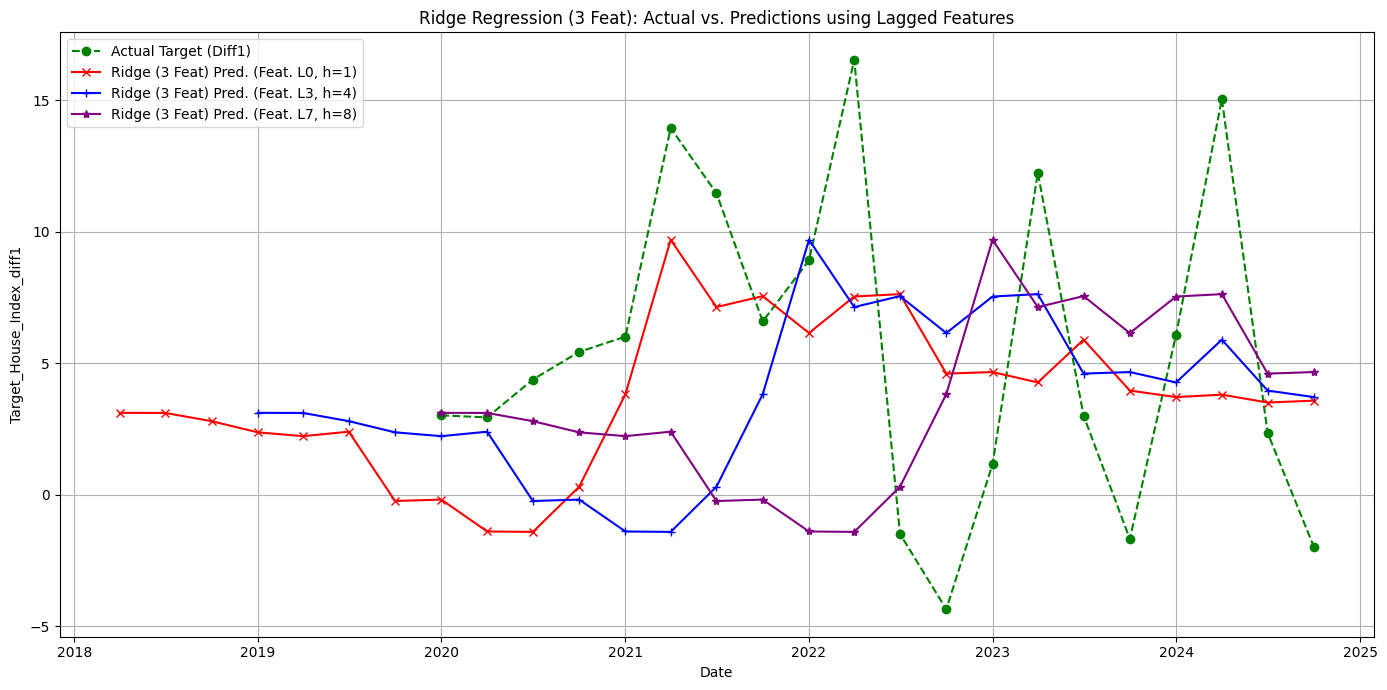

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings

# Suppress convergence and other warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Configuration ---
# Use the 3-feature file specified by the user
input_file = 'DC_Data_For_Lasso_3Feat.csv'
target_column = 'Target_House_Index_diff1'
test_size_ratio = 0.20 # Use last 20% for evaluation
max_feature_lag_eval = 8 # Evaluate using features lagged up to h-1 steps (for h=1 to 8)
n_splits_cv = 5 # For RidgeCV internal cross-validation
alphas_ridge = np.logspace(-4, 4, 100) # Alphas to test for RidgeCV

print(f"--- Evaluating Ridge Regression Performance (3 Features) via Rolling Lagged Features ---")
print(f"Using data: {input_file}")
print(f"Evaluating prediction of y(t) using features X(t-h+1) for h=1 to {max_feature_lag_eval}")

try:
    # --- Step 1: Load Data ---
    df_ridge_eval = pd.read_csv(input_file, parse_dates=['Date'], index_col='Date')
    print(f"Data loaded. Shape: {df_ridge_eval.shape}") # Should be (136, 4)

    # --- Step 2: Find Optimal Ridge Model using RidgeCV ---
    print("\nRunning RidgeCV to find optimal alpha and model components...")
    X_full = df_ridge_eval.drop(columns=[target_column])
    y_full = df_ridge_eval[target_column]
    n_features_ridge = X_full.shape[1] # Should be 3
    print(f"Number of features for Ridge: {n_features_ridge}")


    tscv_ridge = TimeSeriesSplit(n_splits=n_splits_cv, gap=0)
    pipeline_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=alphas_ridge, cv=tscv_ridge, scoring='neg_mean_squared_error'))
    ])

    # Fit on the entire dataset to find the best alpha and final coefficients
    pipeline_ridge.fit(X_full, y_full)
    ridge_model = pipeline_ridge.named_steps['ridge']
    scaler_ridge = pipeline_ridge.named_steps['scaler']
    coefficients_ridge = ridge_model.coef_
    intercept_ridge = ridge_model.intercept_
    optimal_alpha_ridge = ridge_model.alpha_

    print(f"RidgeCV components retrieved (Optimal Alpha={optimal_alpha_ridge:.4f}).")
    print(f"Intercept: {intercept_ridge:.4f}")
    print(f"Coefficients: {coefficients_ridge}")

    # --- Step 3: Setup Rolling Evaluation ---
    n_obs = len(df_ridge_eval)
    n_test = int(n_obs * test_size_ratio)
    n_train_initial = n_obs - n_test

    print(f"\nTotal observations: {n_obs}")
    # Note: Train size is relevant for the split point, not for fitting RidgeCV here
    print(f"Initial training size split point reference: {n_train_initial}")
    print(f"Test set size (for evaluation): {n_test}")

    # Dictionary to store results for each lag h
    all_ridge_results = {}
    all_ridge_metrics = {}

    # --- Step 4: Perform Rolling Predictions using Lagged Features ---
    for h in range(1, max_feature_lag_eval + 1):
        print(f"\nEvaluating for h={h} (using features lagged by {h-1} periods)")
        feature_lag = h - 1
        predictions_h = []
        actuals_h = []
        start_index_pred = n_train_initial + feature_lag
        if start_index_pred >= n_obs:
             print(f"  Not enough data points to evaluate with feature lag {feature_lag}. Skipping h={h}.")
             continue

        eval_indices = df_ridge_eval.index[start_index_pred:]
        print(f"  Evaluating {len(eval_indices)} predictions.")

        for i in range(start_index_pred, n_obs):
            current_eval_date = df_ridge_eval.index[i]
            feature_index = i - feature_lag
            X_lagged = X_full.iloc[[feature_index]]
            X_lagged_scaled = scaler_ridge.transform(X_lagged)
            pred = intercept_ridge + np.dot(X_lagged_scaled, coefficients_ridge)
            predictions_h.append(pred[0])
            actual = y_full.iloc[i]
            actuals_h.append(actual)

        results_df_h = pd.DataFrame(
            {'Actual': actuals_h, f'Prediction (Features L{feature_lag})': predictions_h},
            index=eval_indices
        )
        all_ridge_results[h] = results_df_h

        # --- Calculate Metrics for horizon h ---
        mae = mean_absolute_error(results_df_h['Actual'], results_df_h[f'Prediction (Features L{feature_lag})'])
        rmse = np.sqrt(mean_squared_error(results_df_h['Actual'], results_df_h[f'Prediction (Features L{feature_lag})']))
        if np.any(results_df_h['Actual'] == 0):
             print(f"Warning: Actual values contain zeros at horizon {h}. MAPE might be misleading or infinite.")
             non_zero_actuals = results_df_h['Actual'][results_df_h['Actual'] != 0]
             non_zero_preds = results_df_h[f'Prediction (Features L{feature_lag})'][results_df_h['Actual'] != 0]
             mape = np.mean(np.abs((non_zero_actuals - non_zero_preds) / non_zero_actuals)) if len(non_zero_actuals) > 0 else np.nan
        else:
             mape = mean_absolute_percentage_error(results_df_h['Actual'], results_df_h[f'Prediction (Features L{feature_lag})'])

        # Directional Accuracy
        results_df_h['Actual_Previous'] = y_full.shift(1).reindex(results_df_h.index)
        results_df_h['Actual_Change'] = results_df_h['Actual'] - results_df_h['Actual_Previous']
        results_df_h['Predicted_Change'] = results_df_h[f'Prediction (Features L{feature_lag})'] - results_df_h['Actual_Previous']
        valid_comparison = results_df_h[['Actual_Change', 'Predicted_Change']].dropna()
        correct_direction = (np.sign(valid_comparison['Actual_Change']) == np.sign(valid_comparison['Predicted_Change']))
        directional_accuracy = correct_direction.mean() * 100 if not correct_direction.empty else np.nan

        print(f"  Metrics for h={h} (Features L{feature_lag}):")
        print(f"    MAE:  {mae:.3f}")
        print(f"    RMSE: {rmse:.3f}")
        print(f"    MAPE: {mape:.3f}")
        print(f"    Dir Acc (%): {directional_accuracy:.1f}")

        all_ridge_metrics[h] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape*100, 'Directional Accuracy (%)': directional_accuracy}

    # --- Step 5: Consolidate and Compare Metrics ---
    if all_ridge_metrics:
        metrics_comparison_df_ridge = pd.DataFrame(all_ridge_metrics).T
        metrics_comparison_df_ridge.index.name = 'Horizon (h)'
        print("\n--- Comparison of Ridge Regression (3 Features) Metrics Across Feature Lags ---")
        print(metrics_comparison_df_ridge.to_markdown(floatfmt=".3f"))

        # --- Plot Metrics vs. Horizon h ---
        plt.figure(figsize=(12, 9))
        plt.subplot(4, 1, 1)
        plt.plot(metrics_comparison_df_ridge.index, metrics_comparison_df_ridge['MAE'], marker='o')
        plt.title('Ridge (3 Feat): MAE vs. Horizon h (Using Features L(h-1))')
        plt.ylabel('MAE')
        plt.xticks(metrics_comparison_df_ridge.index)
        plt.grid(True)
        plt.subplot(4, 1, 2)
        plt.plot(metrics_comparison_df_ridge.index, metrics_comparison_df_ridge['RMSE'], marker='o', color='orange')
        plt.title('Ridge (3 Feat): RMSE vs. Horizon h (Using Features L(h-1))')
        plt.ylabel('RMSE')
        plt.xticks(metrics_comparison_df_ridge.index)
        plt.grid(True)
        plt.subplot(4, 1, 3)
        plt.plot(metrics_comparison_df_ridge.index, metrics_comparison_df_ridge['MAPE'], marker='o', color='green')
        plt.title('Ridge (3 Feat): MAPE (%) vs. Horizon h (Using Features L(h-1))')
        plt.ylabel('MAPE (%)')
        plt.xticks(metrics_comparison_df_ridge.index)
        plt.grid(True)
        plt.subplot(4, 1, 4)
        plt.plot(metrics_comparison_df_ridge.index, metrics_comparison_df_ridge['Directional Accuracy (%)'], marker='o', color='red')
        plt.title('Ridge (3 Feat): Directional Accuracy (%) vs. Horizon h (Using Features L(h-1))')
        plt.ylabel('Accuracy (%)')
        plt.xlabel('Horizon (h)')
        plt.xticks(metrics_comparison_df_ridge.index)
        plt.ylim(0, 105)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- Plot Actual vs Select Predictions ---
        plt.figure(figsize=(14, 7))
        # Use the actuals from the longest horizon for plotting base actuals in test period
        # Make sure the key exists before accessing
        max_h_key = max(all_ridge_results.keys()) if all_ridge_results else None
        if max_h_key:
             base_actuals = all_ridge_results[max_h_key]['Actual']
             plt.plot(base_actuals.index, base_actuals, label='Actual Target (Diff1)', color='green', marker='o', linestyle='--')

             horizons_to_plot = [1, 4, 8]
             colors = ['red', 'blue', 'purple']
             markers = ['x', '+', '*']
             for i, h in enumerate(horizons_to_plot):
                 if h in all_ridge_results:
                     feature_lag = h - 1
                     plt.plot(all_ridge_results[h].index, all_ridge_results[h][f'Prediction (Features L{feature_lag})'],
                              label=f'Ridge (3 Feat) Pred. (Feat. L{feature_lag}, h={h})', color=colors[i % len(colors)],
                              marker=markers[i % len(markers)], linestyle='-')

             plt.title(f'Ridge Regression (3 Feat): Actual vs. Predictions using Lagged Features')
             plt.xlabel('Date')
             plt.ylabel('Target_House_Index_diff1')
             plt.legend()
             plt.grid(True)
             plt.tight_layout()
             plt.show()
        else:
             print("No results available to plot forecasts.")

    else:
        print("\nNo metrics were generated for Ridge Regression (3 Features).")

except FileNotFoundError:
    print(f"Error: The file '{input_file}' was not found.")
except KeyError as e:
    print(f"Error: Problem accessing column: {e}")
except ValueError as e:
     print(f"ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred during analysis: {e}")